## Feature Engineering: GMM clustering

In [197]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [198]:
import sys
from pathlib import Path
project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

In [199]:
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
mlflow.set_registry_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
experiment_name = "Production Time Prediction"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///D:/DEV/AIML/ProjectRepos/AzureML/templates/azureml/mlflow/artifacts', creation_time=1779115459900, experiment_id='1', last_update_time=1779115459900, lifecycle_stage='active', name='Production Time Prediction', tags={}, workspace='default'>

In [200]:
import pandas as pd

X_train = pd.read_parquet('../../data/split/production_time_train.parquet')
X_test = pd.read_parquet('../../data/split/production_time_test.parquet')

y_train = pd.read_parquet('../../data/split/production_time_train_target.parquet')['process_time']
y_test = pd.read_parquet('../../data/split/production_time_test_target.parquet')['process_time']

#### Load Preprocessor and Feature Creation Steps

In [201]:
import mlflow.sklearn

feature_creation_step = mlflow.sklearn.load_model("models:/feature_creation/latest")
preprocessor = mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")

#### GMM Clusterer and Feature Adder
I created a GMM clusterer and added the cluster labels as a new feature to the dataset. GMM is the Gaussian Mixture Model, which is a probabilistic model that assumes all the data points are generated from a mixture of several Gaussian distributions with unknown parameters. By fitting a GMM to the data, we can identify hidden relationships and group similar data points together. The cluster labels can provide insights into the underlying structure of the data and can be used for further analysis or as input for other machine learning models.

In [202]:
# gmm_clusterer.py
from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# GMM wrapper
class GMMClusterer(BaseEstimator):
    def __init__(self, n_components=6, random_state=42, max_iter=1000, **kwargs):
        """Wrapper class for GaussianMixture to be used in a pipeline.
        If soft_clusters is True, predict_proba will be used to get cluster probabilities as features.
        If False, predict will be used to get hard cluster labels."""

        self.soft_clusters = kwargs.pop('soft_clusters', False)
        self.n_components = n_components
        self.random_state = random_state
        self.max_iter = max_iter
        self.kwargs = kwargs

    def fit(self, X, y=None):
        self.clusterer = GaussianMixture(
            n_components=self.n_components,
            random_state=self.random_state,
            max_iter=self.max_iter,
            **self.kwargs
        )
        
        if self.soft_clusters:
            self.labels_ = self.clusterer.fit(X).predict_proba(X)
        else:
            self.labels_ = self.clusterer.fit_predict(X)
       
        return self

    def predict(self, X):
        if self.soft_clusters:
            return self.clusterer.predict_proba(X)
        return self.clusterer.predict(X)


# Transformer to add cluster features
class ClusterFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, clusterer, ohe=None):
        """Clusterer Feature Adder wrapper class for adding GMM cluster features to the dataset.
        If ohe is provided, it will be used to one-hot encode hard cluster labels.
        For soft clusters, the cluster probabilities will be added directly as features."""

        self.clusterer = clusterer
        self.ohe = ohe if not self.clusterer.soft_clusters else None  # OHE only for hard clusters

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            # if DataFrame, store column names
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        else:
            # if NumPy, create generic names (x0, x1, ...)
            self.feature_names_in_ = np.array(
                [f"x{i}" for i in range(X.shape[1])], 
                dtype=object
            )

        X_converted = self.get_X_converted(X)

        self.clusterer.fit(X_converted)

        if hasattr(self.clusterer, 'labels_'):
            clusters = self.clusterer.labels_
        else:
            clusters = self.clusterer.predict(X_converted)

        if self.ohe is not None:
            clusters = self.ohe.fit_transform(clusters.reshape(-1, 1))

        self.is_fitted_ = True # IMPORTANT!

        return self


    def transform(self, X):
        # return X
        X_converted = self.get_X_converted(X)
        
        clusters = self.clusterer.predict(X_converted)
        if self.ohe is not None:
            clusters = self.ohe.transform(clusters.reshape(-1, 1))

        return np.column_stack([X, clusters])
    

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        
        # if ohe set (hard clusters, ohe)
        if self.ohe is not None:
            ohe_feature_names = self.ohe.get_feature_names_out(["cluster_id"])
            return np.append(input_features, ohe_feature_names)
        
        # if soft clusters, add one feature per cluster
        if self.clusterer.soft_clusters:
            cluster_feature_names = [
                f"cluster_{i}" for i in range(self.clusterer.n_components)
            ]
            return np.append(input_features, cluster_feature_names)

        # hard clusters, no ohe (single cluster_id feature)
        return np.append(input_features, "cluster_id")
    

    def get_X_converted(self, X):
        """ Helper method to convert X to NumPy array 
            if it's a DataFrame, ensuring it's contiguous 
            and of type float32. """
        return np.ascontiguousarray(
            X.to_numpy() 
            if hasattr(X, 'to_numpy') 
            else X, dtype=np.float32
        )
    

##### Save GMM Clusterer and Feature Adder classes
to file: `notebooks/utils/artifacts/gmm_clusterer.py`

In [ ]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path="../utils/artifacts/gmm_clusterer.py",
)

---

#### Optuna

In the Optuna trials I'm going to use fit of whole pipeline with GMM clustering step in it to avoid data leakage. This way GMM will be fitted only on training data partition of each fold. The downside of this approach is that each fold will have different clusters and different feature space after clustering, but it will give us more realistic estimate of model performance. The only parameter of GMM that I will optimize is number of clusters. I will use RMSE as the metric to minimize, cause it is more interpretable for regression problems than R^2 and it is more sensitive to large errors, which is important in my case, because I want to avoid large prediction errors in production. I will also log the best number of clusters for each fold and the corresponding RMSE, so we can analyze the results later and compare with test set performance. 

#### Optuna Helper Static Class

In [ ]:
# optuna_study.py
import pandas as pd
import numpy as np
import warnings
from IPython.display import display, Markdown
from sklearn.model_selection import cross_validate
from sklearn.exceptions import ConvergenceWarning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

class OptunaStudy:
    @staticmethod
    def cross_validate(
        trial, 
        model, 
        X_train, 
        y_train, 
        variance_penalty=True,  # True for optimizing stability
        ):
        try:

            # -------------------
            # CV 
            # -------------------
            scores = cross_validate(
                model, 
                X_train, y_train, 
                cv=5, 
                scoring={
                    'RMSE': 'neg_root_mean_squared_error', 
                    'MAE': 'neg_mean_absolute_error', 
                    'R^2': 'r2'
                },
                n_jobs=-1
            )

            # -------------------
            # METRIC CALCULATION
            # -------------------
            mean_rmse = -scores['test_RMSE'].mean()
            mean_mae = -scores['test_MAE'].mean()
            mean_r2 = scores['test_R^2'].mean()

            # std dev of RMSE across folds (for stability analysis)
            std_rmse = np.std(-scores['test_RMSE'])
            

            # -------------------
            # FIT ON SAMPLE
            # -------------------
            X_sample, y_sample = OptunaStudy._get_sample(X_train, y_train)
            model.fit(X_sample, y_sample)

            # -------------------
            # CONVERGENCE SIGNAL
            # -------------------
            converged, n_iter_max_ratio = OptunaStudy._get_convergence_signal(model)
            trial.set_user_attr("converged", bool(converged))
            trial.set_user_attr("n_iter_max_ratio", float(n_iter_max_ratio))

            # -------------------
            # CONDITION NUMBER
            # -------------------
            condition_number = OptunaStudy._get_cond_num(model, X_sample)
            trial.set_user_attr("condition_number", condition_number)

            # -------------------
            # OBJECTIVE 
            # -------------------
            is_quantile = hasattr(model[-1], "quantile") and model[-1].quantile is not None
            
            pinball = None
            coverage = None
            coverage_error = None
            if is_quantile:
                # For quantile regression, we want to minimize the pinball loss
                # which is asymmetric. We can use the mean absolute error as a proxy,
                # but we should also consider the quantile level.
                ql = model[-1].quantile
                y_pred = model.predict(X_sample)
                err = y_sample - y_pred

                pinball = np.mean(np.maximum(ql * err, (ql - 1) * err))
                coverage = np.mean(y_pred >= y_sample)
                coverage_error = abs(coverage - ql)

                score = pinball + 10.0 * coverage_error  # penalize coverage deviation
            else:
                # For standard regression, we want to minimize RMSE
                score = mean_rmse

            # --------------------
            # PENALTIES
            # --------------------
            # performance instability
            if variance_penalty:
                # penalize ill-conditioned transformations
                cv_penalty  = std_rmse / (mean_rmse + 1e-8)
                score *= (1 + cv_penalty)


            # Define safety thresholds for matrix conditioning
            MAX_SAFE_COND = 500.0

            # structural instability (orthogonal signal)
            if condition_number > MAX_SAFE_COND:
                # heavy penalty
                violation_magnitude = condition_number / MAX_SAFE_COND
                score += 10.0 * violation_magnitude
            else:
                # soft penalty
                cond_penalty = np.log10(condition_number + 1)
                score += 0.01 * cond_penalty

            # --------------------
            # LOGGING
            # --------------------
            # save additional metrics in "attributes" of the trial
            trial.set_user_attr("RMSE", mean_rmse)
            trial.set_user_attr("MAE", mean_mae)
            trial.set_user_attr("R2", mean_r2)
            trial.set_user_attr("RMSE_std", std_rmse)

            # save all fold scores for later analysis
            trial.set_user_attr("fold_RMSE", (-scores['test_RMSE']).tolist())
            trial.set_user_attr("fold_MAE", (-scores['test_MAE']).tolist())
            trial.set_user_attr("fold_R2", scores['test_R^2'].tolist())
            
            # save quantile regression specific metrics
            trial.set_user_attr("pinball_loss", pinball)
            trial.set_user_attr("coverage", coverage)
            trial.set_user_attr("coverage_error", coverage_error)


            return score
        
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    
    @staticmethod
    def _get_convergence_signal(model, step_name="regressor"):
        """ Helper method to check if the regressor converged 
            and how many iterations it took. """
        reg = model.named_steps[step_name]

        n_iter = getattr(reg, "n_iter_", None)
        max_iter = getattr(reg, "max_iter", None)

        # models without iterative optimization
        if n_iter is None or max_iter is None:
            return True, 0.0

        n_iter_arr = np.atleast_1d(n_iter)

        converged = np.all(n_iter_arr < max_iter)
        n_iter_max_ratio = np.mean(n_iter_arr / max_iter)

        return bool(converged), float(n_iter_max_ratio)


    @staticmethod
    def _get_cond_num(model, X_sample):
        """ Helper method to calculate the condition 
            number of the transformed feature space
            before the regressor. """
        if not hasattr(model[-1], "predict"):
            return 1.0  # if no regressor, return perfect condition number
        if not hasattr(model[:-1], "transform"):
            return 1.0  # if no transformations, return perfect condition number
        X_transformed = model[:-1].transform(X_sample)
        return np.linalg.cond(X_transformed)

    
    @staticmethod
    def _get_sample(X, y, n_samples=1000):
        """Helper method to get a deterministic sample of the data for fitting."""
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)  # convert to DataFrame for consistent sampling
        X_sample = X.sample(n=min(n_samples, len(X)), random_state=42)
        y_sample = y.loc[X_sample.index]
        return X_sample, y_sample


    @staticmethod
    def display_optuna_results(mlflow, study, run_name="feature_engineering"):
        with mlflow.start_run(run_name=run_name) as run:     
            results_df = pd.DataFrame({
                'mean_scores': [
                    study.best_trial.user_attrs['RMSE'],
                    study.best_trial.user_attrs['MAE'], 
                    study.best_trial.user_attrs['R2']
                ]
            }, index=['RMSE', 'MAE', 'R2'])

            fold_scores_df = pd.DataFrame({
                'RMSE': study.best_trial.user_attrs['fold_RMSE'],
                'MAE': study.best_trial.user_attrs['fold_MAE'],
                'R2': study.best_trial.user_attrs['fold_R2']
            }, index=[f'Fold {i+1}' for i in range(5)])
            
            joined_df = pd.concat([results_df.T, fold_scores_df], axis=0)

            n_trials = len(study.trials)

            # log best hyperparameters and metrics to MLflow
            mlflow.log_params(study.best_trial.params)
            mlflow.log_metric("optuna_trials", n_trials)
            mlflow.log_metrics(results_df['mean_scores'].to_dict())
            # log fold scores as a table (optional, for detailed analysis)

            # fold_scores_df.round(4).to_parquet("__fold_scores.parquet")
            mlflow.log_table(fold_scores_df.round(4), artifact_file="fold_scores.parquet")
            # Path("__fold_scores.parquet").unlink()

            name = (
                f"Run: `{run_name}`, Trials: {n_trials}"
            )
            display(Markdown(f"> ### {run_name}"))
            display(Markdown(f"##### {name}"))
            display(joined_df.T.round(4))

            display(Markdown("### Best Hyperparameters:"))
            display(pd.DataFrame(study.best_params, index=["value"]).T)

In [205]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path="../utils/utilities/optuna_study.py",
    )

#### Adaptive Budgeting Approach for Optuna Study

In [206]:
from notebooks.utils.utilities.adaptive_budget import AdaptiveOptunaBudget

#### Regressor getter function
This function will return the appropriate regression model based on the input parameters. It will support Ridge, Lasso, ElasticNet, XGBRegressor, and LGBMRegressor. The function will also handle the hyperparameters for each model type, which will be suggested by Optuna during the optimization process.

In [207]:
from lightgbm import LGBMRegressor
import optuna
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

def get_regressor(trial, model_type):
    if model_type == 'Ridge':
        model = Ridge(
            alpha=trial.suggest_float('ridge_alpha', 1e-3, 100.0, log=True),
            random_state=42
        )
    elif model_type == 'Lasso':
        model = Lasso(
            alpha=trial.suggest_float('lasso_alpha', 1e-4, 10.0, log=True),
            max_iter=50000,
            random_state=42
        )
    elif model_type == 'ElasticNet':
        model = ElasticNet(
            max_iter=50000, 
            alpha=trial.suggest_float('elasticnet_alpha', 1e-4, 10.0, log=True), 
            l1_ratio=trial.suggest_float('elasticnet_l1_ratio', 0.01, 0.99),
            random_state=42
        )
    elif model_type == 'XGBRegressor':
        model = XGBRegressor(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 300), 
            max_depth=trial.suggest_int('xgb_max_depth', 3, 7), 
            learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.2, log=True), 
            # regularization to prevent overfitting for 2800 rows
            min_child_weight=trial.suggest_int('xgb_min_child_weight', 1, 20),
            subsample=trial.suggest_float('xgb_subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
            random_state=42,
            n_jobs=1 # parallelism is already handled in cv
        )
    elif model_type == 'LGBMRegressor':
        max_depth = trial.suggest_int('lgbm_max_depth', 4, 7) # 2^4=16, 2^7=128, num_leaves must be less than 2^max_depth
        num_leaves = min(31, 2 ** max_depth - 1)
        model = LGBMRegressor(
            n_estimators=trial.suggest_int('lgbm_n_estimators', 100, 1000), 
            max_depth=max_depth, 
            num_leaves=num_leaves,
            min_child_samples=trial.suggest_int('lgbm_min_child_samples', 10, 60),
            learning_rate=trial.suggest_float('lgbm_learning_rate', 0.01, 0.1, log=True), 
            # ridge regularization to prevent overfitting
            reg_lambda=trial.suggest_float('lgbm_reg_lambda', 1e-3, 10.0, log=True),
            random_state=42,
            n_jobs=1, # parallelism is already handled in cv
            importance_type='gain',
            objective='regression', # RMSE, for MAE use 'mae'
            verbosity=-1
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    return model

#### Objective function for Linear Models with GMM Clustering

In [208]:
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_pipeline(trial, cfg):
    (
        model_type, 
        use_clusterer, 
        use_gmm_ohe,
        variance_penalty
    ) = cfg

    steps = [
        ('feature_creation', feature_creation_step),
        ('preprocess', preprocessor),
    ]
    
    if use_clusterer:
        steps.append(('cluster_feature', ClusterFeatureAdder(
            GMMClusterer(
                n_components=trial.suggest_int('n_clusters', 2, 6),
                random_state=42,
                max_iter=5000,
                reg_covar=1e-3,  # regularization to prevent singular covariance matrices
                soft_clusters=trial.suggest_categorical('soft_clusters', [True, False])
            ),
            ohe=OneHotEncoder(
                sparse_output=False, 
                handle_unknown='ignore',
                drop='first'
            ) if use_gmm_ohe else None
        )))
 
    steps.append(('regressor', get_regressor(trial, model_type)))

    # build Pipeline
    eval = Pipeline(steps=steps)
   
    # fit and evaluate the model using cross-validation
    return OptunaStudy.cross_validate(
        trial, 
        eval, 
        X_train, y_train, 
        variance_penalty=variance_penalty
        )



def objective_adaptive(        
        trial, 
        budget,
        models: list[str],
        use_clusterer_opts=[True, False],
        use_gmm_ohe_opts=[True],
        variance_penalty_opts=[False],
        ):
    
    cfg = (
        trial.suggest_categorical('model_type', models),
        trial.suggest_categorical('use_clusterer', use_clusterer_opts),
        trial.suggest_categorical('use_gmm_ohe', use_gmm_ohe_opts),
        trial.suggest_categorical('variance_penalty', variance_penalty_opts)
    )

    # Check if we should stop early based on the adaptive budget
    if budget.should_stop(cfg):
        raise optuna.TrialPruned()

    score = run_pipeline(trial, cfg)

    budget.update(cfg, score)

    return score



In [209]:
def get_run_title_(cfg):
    def if_valid(feature_name):
        return hasattr(cfg, feature_name) and getattr(cfg, feature_name)
    cfg_string = f"{cfg.model}"
    cfg_string += " | Clusterer" if if_valid('use_clusterer') else ""
    cfg_string += " | VarPenalty" if if_valid('var_penalty') else ""

    return f"AdaptiveOpt_{cfg_string}"

In [210]:
from optuna.pruners import MedianPruner

def run_experiments(configs, global_budget=200, adaptive_budget_params=None):
    # scores_list = []    # accumulate scores for summary dataframe
    results = []      # accumulate (cfg, study, converged) for detailed analysis

    for cfg in configs:
        print(f"Optimizing {get_run_title_(cfg)}...")

        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
        
        budget = AdaptiveOptunaBudget(
            base_trials=20,
            patience=25,
            min_improve=1e-3,
            ascending=False,
            **(adaptive_budget_params or {})
        )

        study.optimize(
            lambda trial: objective_adaptive(
                trial, 
                budget=budget,
                models=[cfg.model],
                use_clusterer_opts=[cfg.use_clusterer],
                use_gmm_ohe_opts=[cfg.use_gmm_ohe],
                variance_penalty_opts=[cfg.var_penalty]
            ),
            n_trials=global_budget,
            n_jobs=1
        )

        converged = budget.no_improve[cfg] < budget.patience

        results.append((cfg, study, converged))
    
    return results


def aggregate_results(results):
    trails_list = []
    for cfg, study, converged in results:
        use_clusterer = study.best_trial.params.get('use_clusterer', True)
        use_var_penalty = cfg.var_penalty
        study_name = (
            f"{cfg.model.lower()}"
            + f"{'_vp' if use_var_penalty else ''}"
            + f"{'_c' if use_clusterer else ''}"
        )

        trails_list.append({
            'study': study,
            'study_name': study_name,
            
            'Model': study.best_trial.params.get('model_type'),
            'Optuna Score': study.best_value,

            # settings
            'Use Clusterer': '✔' if study.best_trial.params.get('use_clusterer', False) else '',
            'Variance Penalty': '✔' if cfg.var_penalty else '',

            # main regression metrics
            'RMSE': study.best_trial.user_attrs.get("RMSE", None),
            'MAE': study.best_trial.user_attrs.get("MAE", None),
            'R2': study.best_trial.user_attrs.get("R2", None),
            'RMSE Std': study.best_trial.user_attrs.get("RMSE_std", None),

            # quantile regression metrics
            'pinball_loss': study.best_trial.user_attrs.get("pinball_loss", None),
            'coverage': study.best_trial.user_attrs.get("coverage", None),
            'coverage_error': study.best_trial.user_attrs.get("coverage_error", None),
            
            # stability and convergence indicators
            'Condition Number': study.best_trial.user_attrs.get("condition_number", None),
            'Converged': '✔' if converged else '✘',

            'Best': '',

            # additional info for analysis
            'base_model': study.best_trial.params.get('model_type').lower(),
            'best_params': study.best_params,
            'fold_scores': {
                'RMSE': study.best_trial.user_attrs['fold_RMSE'],
                'MAE': study.best_trial.user_attrs['fold_MAE'],
                'R2': study.best_trial.user_attrs['fold_R2']
            },
        })
    
    return trails_list

In [211]:
def mark_best_models(df, score_col='Optuna Score', group_col='Model', ascending=True):
    """ Marks the best model per group based on the specified score column."""
    for model in df[group_col].unique():
        if ascending:
            best_idx = df[df[group_col] == model][score_col].idxmin()
        else:
            best_idx = df[df[group_col] == model][score_col].idxmax()
        df.loc[best_idx, 'Best'] = '✔'

In [212]:
from IPython.display import display, Markdown

def display_optuna_results(
        scores_list,
        sort_by='Optuna Score',
        subset_cols=['Model', 'Use Clusterer', 'Use Poly'],

        best_in_group='Optuna Score',
        group_by='Model',
        best_ascending=True,

        std_metrics=True, 
        quantile_metrics=False,
        additional_metrics_cols=[]
        ):
    
    display_columns = subset_cols + ['Optuna Score'] + (
        ['RMSE', 'MAE', 'R2'] if std_metrics else []
    ) + additional_metrics_cols + (
        ['pinball_loss', 'coverage', 'coverage_error'] if quantile_metrics else []
    ) + ['Best']

    df = (pd.DataFrame(scores_list, columns=display_columns)
        .sort_values(sort_by)
        .drop_duplicates(subset=subset_cols, keep='first')
        .fillna('')
        .reset_index(drop=True))

    mark_best_models(
        df, 
        score_col=best_in_group, 
        group_col=group_by, 
        ascending=best_ascending)

    display(df)
    display(Markdown(
        f"**Note:** Best '{best_in_group}' per '{group_by}' "
        f"are marked with ✔ in the 'Best' column."))

#### Run Optuna Trials for Linear Models with GMM Clustering
For each fold, I will run Optuna trials for Ridge, Lasso, and ElasticNet regression models using the GMM cluster probabilities as features. The objective function for each trial will fit the entire pipeline (including GMM clustering) on the training data of the fold and evaluate the RMSE on the validation set. I will log the best hyperparameters (e.g. alpha for Ridge and Lasso, alpha and l1_ratio for ElasticNet) along with the best number of clusters from the GMM step for each model and fold.

The downside of this approach is that feature space will be different for each fold due to different GMM cluster assignments, which may lead to variability in model performance across folds. However, this method provides a more realistic estimate of how the model will perform on unseen data, as it avoids data leakage from fitting the GMM on the entire dataset before cross-validation.

In [213]:
from dataclasses import dataclass
from itertools import product

@dataclass(frozen=True)
class ExperimentConfig:
    model: str
    use_clusterer: bool
    use_gmm_ohe: bool
    var_penalty: bool

cfg_gmm_lin = [
    ExperimentConfig(
        model=model, 
        use_clusterer=use_clusterer,
        use_gmm_ohe=use_clusterer,  # for linear models always add OHE if using clusterer
        var_penalty=var_penalty
        )
    for model, use_clusterer, var_penalty in product(
        ['Ridge', 'Lasso', 'ElasticNet'], 
        [True, False],  # use_clusterer
        [False]         # var_penalty not used yet
    )
]

In [214]:
opt_results_lin = run_experiments(cfg_gmm_lin, global_budget=1000)

Optimizing AdaptiveOpt_Ridge | Clusterer...
Optimizing AdaptiveOpt_Ridge...
Optimizing AdaptiveOpt_Lasso | Clusterer...
Optimizing AdaptiveOpt_Lasso...
Optimizing AdaptiveOpt_ElasticNet | Clusterer...
Optimizing AdaptiveOpt_ElasticNet...


In [215]:
trails_list = aggregate_results(opt_results_lin)

In [ ]:
display_optuna_results(
    trails_list,
    sort_by='RMSE',
    best_in_group='RMSE',
    subset_cols=['Model', 'Use Clusterer'],
    additional_metrics_cols=['RMSE Std', 'Condition Number']
)

,Model,Use Clusterer,Optuna Score,RMSE,MAE,R2,RMSE Std,Condition Number,Best
0,ElasticNet,✔,3.994086e+13,39.250431,18.216710,0.839347,13.129203,1.997043e+15,✔
1,ElasticNet,,4.678088e+13,39.280021,18.215460,0.839078,13.102727,2.339044e+15,
2,Ridge,,4.678088e+13,39.283670,18.230694,0.839102,13.089309,2.339044e+15,✔
3,Lasso,,4.678088e+13,39.408637,18.253440,0.838043,13.094715,2.339044e+15,✔
4,Ridge,✔,3.994086e+13,39.417269,18.274110,0.837810,13.183236,1.997043e+15,
5,Lasso,✔,3.994086e+13,39.417321,18.273780,0.837808,13.184242,1.997043e+15,


**Note:** Best 'RMSE' per 'Model' are marked with ✔ in the 'Best' column.

In [ ]:
for trail in trails_list:
    study_name = trail.get('study_name')
    print(f"Displaying results for {study_name}")
    OptunaStudy.display_optuna_results(
        mlflow, 
        trail.get('study'), 
        f"optuna_linear_models_{study_name}")

Displaying results for ridge_c


> ### optuna_linear_models_ridge_c

##### Run: `optuna_linear_models_ridge_c`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.4173,28.9721,56.5108,54.5483,27.6385,29.4166
MAE,18.2741,16.2193,20.9198,19.8800,17.0234,17.3280
R2,0.8378,0.8868,0.7628,0.7074,0.9040,0.9280


### Best Hyperparameters:

,value
model_type,Ridge
use_clusterer,True
use_gmm_ohe,True
variance_penalty,False
n_clusters,6
soft_clusters,True
ridge_alpha,0.008261


Displaying results for ridge


> ### optuna_linear_models_ridge

##### Run: `optuna_linear_models_ridge`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.2837,28.8155,56.2573,54.2920,27.4565,29.5970
MAE,18.2307,16.1585,20.7410,19.7683,16.9135,17.5721
R2,0.8391,0.8880,0.7649,0.7101,0.9053,0.9271


### Best Hyperparameters:

,value
model_type,Ridge
use_clusterer,False
use_gmm_ohe,False
variance_penalty,False
ridge_alpha,56.698495


Displaying results for lasso_c


> ### optuna_linear_models_lasso_c

##### Run: `optuna_linear_models_lasso_c`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.4173,28.9731,56.5107,54.5508,27.6342,29.4178
MAE,18.2738,16.2187,20.9204,19.8807,17.0204,17.3287
R2,0.8378,0.8868,0.7628,0.7074,0.9041,0.9280


### Best Hyperparameters:

,value
model_type,Lasso
use_clusterer,True
use_gmm_ohe,True
variance_penalty,False
n_clusters,6
soft_clusters,True
lasso_alpha,0.000826


Displaying results for lasso


> ### optuna_linear_models_lasso

##### Run: `optuna_linear_models_lasso`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.4086,29.2096,56.3323,54.4709,27.3486,29.6818
MAE,18.2534,16.1850,20.7997,19.8362,16.9343,17.5121
R2,0.8380,0.8849,0.7643,0.7082,0.9060,0.9267


### Best Hyperparameters:

,value
model_type,Lasso
use_clusterer,False
use_gmm_ohe,False
variance_penalty,False
lasso_alpha,0.098467


Displaying results for elasticnet_c


> ### optuna_linear_models_elasticnet_c

##### Run: `optuna_linear_models_elasticnet_c`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.2504,28.6213,56.2794,54.3025,27.4614,29.5875
MAE,18.2167,16.0989,20.7609,19.7700,16.9500,17.5039
R2,0.8393,0.8895,0.7648,0.7100,0.9052,0.9272


### Best Hyperparameters:

,value
model_type,ElasticNet
use_clusterer,True
use_gmm_ohe,True
variance_penalty,False
n_clusters,6
soft_clusters,True
elasticnet_alpha,0.038634
elasticnet_l1_ratio,0.495504


Displaying results for elasticnet


> ### optuna_linear_models_elasticnet

##### Run: `optuna_linear_models_elasticnet`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,39.2800,28.8499,56.2399,54.3365,27.4140,29.5598
MAE,18.2155,16.1298,20.7386,19.7935,16.9017,17.5137
R2,0.8391,0.8877,0.7651,0.7097,0.9056,0.9273


### Best Hyperparameters:

,value
model_type,ElasticNet
use_clusterer,False
use_gmm_ohe,False
variance_penalty,False
elasticnet_alpha,0.017489
elasticnet_l1_ratio,0.120924


Astronomic condition number for each trial means that the feature space is highly collinear, which can lead to unstable model coefficients and poor generalization. There wasnt any take made to address this issue yet, while many optimizations done so far have introduced potential collinearity, such as adding cluster probabilities as features or previously domain knowledge based feature engineering steps. I intentionally skip this for now, cause I want to introduce one more optimization step - Polynomial Features - in the next notebook, which will further increase collinearity, and only then I will apply appropriate regularization techniques to address it. This way I leave all created features for Polynomial combinations and prune them together with regularization, instead of pruning them beforehand and potentially losing useful features.

---

#### Tree Based Models (XGBoost, LightGBM) Optuna Trials
I will run the Optuna trials for tree-based models (XGBoost and LightGBM) for 200 trials each, which should be sufficient to find good hyperparameters while keeping the computational time reasonable. I will also divide trails by use of clusterer to analyze the impact of GMM clustering on model performance. Tree based models are generally considered self sufficient in handling feature segmentation and interactions, so I expect that the addition of GMM cluster probabilities may not significantly improve performance, but it will be interesting to see the results and compare with linear models.

In [218]:
from itertools import product

cfg_gmm_tree = [
    ExperimentConfig(
        model=model, 
        use_clusterer=use_clusterer,
        use_gmm_ohe=False,  # for tree-based models, OHE is not necessary even with clusterer
        var_penalty=var_penalty
        )
    for model, use_clusterer, var_penalty in product(
        ['XGBRegressor', 'LGBMRegressor'],
        [True, False],  # use_clusterer
        [False]         # var_penalty not used yet
    )
]

In [219]:
opt_results_tree = run_experiments(cfg_gmm_tree, global_budget=1000)

Optimizing AdaptiveOpt_XGBRegressor | Clusterer...
Optimizing AdaptiveOpt_XGBRegressor...
Optimizing AdaptiveOpt_LGBMRegressor | Clusterer...
Optimizing AdaptiveOpt_LGBMRegressor...


In [220]:
trails_list_tree = aggregate_results(opt_results_tree)

In [221]:
display_optuna_results(
    trails_list_tree,
    sort_by='RMSE',
    best_in_group='RMSE',
    subset_cols=['Model', 'Use Clusterer'],
    additional_metrics_cols=['RMSE Std', 'Condition Number']
)

,Model,Use Clusterer,Optuna Score,RMSE,MAE,R2,RMSE Std,Condition Number,Best
0,XGBRegressor,✔,3.994086e+13,40.277119,18.051767,0.833015,12.804407,1.997043e+15,✔
1,XGBRegressor,,4.678088e+13,40.419622,18.117986,0.831616,12.563832,2.339044e+15,
2,LGBMRegressor,✔,3.994086e+13,42.499653,19.099037,0.814026,14.313019,1.997043e+15,✔
3,LGBMRegressor,,4.678088e+13,43.386894,19.569807,0.806818,13.793859,2.339044e+15,


**Note:** Best 'RMSE' per 'Model' are marked with ✔ in the 'Best' column.

In [222]:
for trail in trails_list_tree:
    study_name = trail.get('study_name')
    print(f"Displaying results for {study_name}")
    OptunaStudy.display_optuna_results(
        mlflow, 
        trail.get('study'), 
        f"optuna_tree_models_{study_name}")

Displaying results for xgbregressor_c


> ### optuna_tree_models_xgbregressor_c

##### Run: `optuna_tree_models_xgbregressor_c`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,40.2771,26.6097,59.0599,51.9852,32.7551,30.9757
MAE,18.0518,15.6422,20.1752,18.8922,17.5414,18.0078
R2,0.8330,0.9045,0.7409,0.7343,0.8652,0.9202


### Best Hyperparameters:

,value
model_type,XGBRegressor
use_clusterer,True
use_gmm_ohe,False
variance_penalty,False
n_clusters,6
soft_clusters,True
xgb_n_estimators,131
xgb_max_depth,3
xgb_learning_rate,0.064158
xgb_min_child_weight,4


Displaying results for xgbregressor


> ### optuna_tree_models_xgbregressor

##### Run: `optuna_tree_models_xgbregressor`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,40.4196,28.3380,58.6219,52.4693,32.2528,30.4161
MAE,18.1180,16.1710,20.0187,18.9803,17.4451,17.9748
R2,0.8316,0.8917,0.7448,0.7293,0.8693,0.9230


### Best Hyperparameters:

,value
model_type,XGBRegressor
use_clusterer,False
use_gmm_ohe,False
variance_penalty,False
xgb_n_estimators,241
xgb_max_depth,3
xgb_learning_rate,0.04743
xgb_min_child_weight,3
xgb_subsample,0.754274
xgb_colsample_bytree,0.675205


Displaying results for lgbmregressor_c


> ### optuna_tree_models_lgbmregressor_c

##### Run: `optuna_tree_models_lgbmregressor_c`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,42.4997,25.8729,62.6271,56.3122,32.8208,34.8652
MAE,19.0990,15.7117,21.8066,20.4812,18.1577,19.3380
R2,0.8140,0.9097,0.7087,0.6882,0.8647,0.8989


### Best Hyperparameters:

,value
model_type,LGBMRegressor
use_clusterer,True
use_gmm_ohe,False
variance_penalty,False
n_clusters,6
soft_clusters,True
lgbm_max_depth,4
lgbm_n_estimators,596
lgbm_min_child_samples,31
lgbm_learning_rate,0.082998


Displaying results for lgbmregressor


> ### optuna_tree_models_lgbmregressor

##### Run: `optuna_tree_models_lgbmregressor`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,43.3869,26.9878,62.6065,56.8297,35.0600,35.4505
MAE,19.5698,16.5535,22.1111,20.8621,18.8369,19.4854
R2,0.8068,0.9018,0.7089,0.6824,0.8456,0.8955


### Best Hyperparameters:

,value
model_type,LGBMRegressor
use_clusterer,False
use_gmm_ohe,False
variance_penalty,False
lgbm_max_depth,6
lgbm_n_estimators,664
lgbm_min_child_samples,31
lgbm_learning_rate,0.073553
lgbm_reg_lambda,0.257807



---
#### Results and Analysis

Results are quite interesting, it seems that the use of GMM cluster features does not significantly affect the performance of tree-based models, but it even slightly worsens it in fact. This could be because tree-based models are already good at capturing complex interactions and non-linear relationships in the data, so the additional cluster features may not provide much new information and could even introduce noise. On the other hand, for linear models, the use of GMM cluster features seems to have a more consistent positive impact on performance, but its magnitude is very small. This suggests that while the cluster features may help linear models capture some additional structure in the data, they are not a game-changer and the improvement is marginal. Overall, it seems that the GMM clustering step may not be necessary for tree-based models, but it could provide a slight boost for linear models, although the benefits may not be significant enough to justify the added complexity in the pipeline.


---
#### Visualization of GMM Clusters
To visualize the GMM clusters, I will use t-SNE to reduce the dimensionality of the feature space to 2D and then plot the data points colored by their assigned cluster labels. This will help us understand how the GMM has segmented the data and whether the clusters correspond to any meaningful patterns in the feature space. Additionally, I will perform parallel coordinate plots to visualize the distribution of features across different clusters, which can provide insights into the characteristics of each cluster and how they differ from each other.

#### Pipeline factory function
This function will create a machine learning pipeline that includes the GMM clustering step and the regression model. The function will take parameters for the number of clusters in the GMM and the type of regression model to use. The pipeline will first apply the GMM clustering to the input data, then add the cluster probabilities as new features, and finally fit the specified regression model on the augmented feature set.

In [234]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

def pipeline_factory(
    n_components=3,
    random_state=42,
    max_iter=1000,
    soft_clusters=True,
    use_ohe=False      
    ):
    """Factory function to create a pipeline with GMM clustering and optional one-hot encoding of hard cluster labels.
    Parameters:
- n_components: Number of GMM clusters.
- random_state: Random state for reproducibility.
- max_iter: Maximum iterations for GMM convergence.
- soft_clusters: If True, use soft clustering (probabilities). If False, use hard cluster labels.
- use_ohe: If True and soft_clusters is False, apply one-hot encoding to hard cluster labels. Ignored if soft_clusters is True.
    """
    return Pipeline([
        ("feature_creation", feature_creation_step),
        ("preprocess", preprocessor),
        ("cluster_feat", 
            ClusterFeatureAdder(
                GMMClusterer(
                    n_components=n_components,   # number of clusters
                    random_state=random_state, 
                    max_iter=max_iter,
                    soft_clusters=soft_clusters  # set to True for soft clustering
                ),
                ohe=OneHotEncoder(
                    sparse_output=False,
                    handle_unknown='ignore',
                    drop='first'
                ) if use_ohe else None
            ),
        )
    ])

#### Soft Clustering Pipeline
No ohe step is needed when using soft clustering, as we will be adding the probabilities directly as features.

In [239]:
best_linear_gmm_ = (
    pd.DataFrame(opt_results_lin)
    .dropna()[1]
    .apply(lambda s: {**s.best_trial.user_attrs, **{'params': s.best_trial.params}})
    .apply(pd.Series)
    .sort_values(by='RMSE').T[0]
)

print("Best Linear Model with GMM Clusterer:")
display(best_linear_gmm_.params)

Best Linear Model with GMM Clusterer:


{'model_type': 'Ridge',
 'use_clusterer': True,
 'use_gmm_ohe': True,
 'variance_penalty': False,
 'n_clusters': 6,
 'soft_clusters': True,
 'ridge_alpha': 0.008260808399079604}

In [240]:
pipeline = pipeline_factory(
    n_components=best_linear_gmm_.params['n_clusters'],
    random_state=42,
    max_iter=1000,
    soft_clusters=best_linear_gmm_.params['soft_clusters'],
    use_ohe=False 
)
pipeline.set_output(transform="pandas")

pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

#### t-SNE on GMM Cluster Probabilities
Reduce dimensionality of the soft cluster coordinates to 2D for visualization for visual inspection of cluster separation and uncertainty.

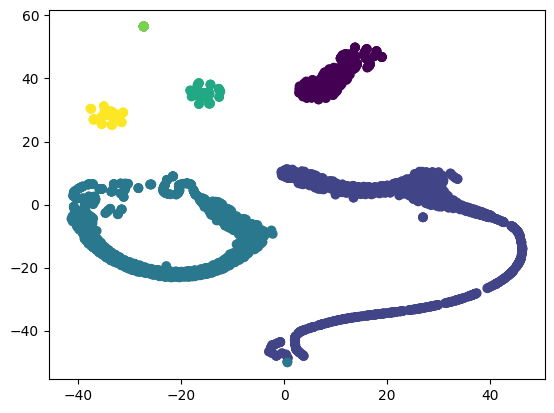

In [241]:
from sklearn.manifold import TSNE

X_clustered = pipeline.transform(X_train)

# get columns with cluster probabilities (those with prefix cluster_)
prob_cols = [c for c in X_clustered.columns if 'cluster_' in c]

# t-SNE on the "soft" cluster coordinates
soft_coords = X_clustered[prob_cols].values
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(soft_coords)

# for labels (colors) get highest probability cluster
labels = np.argmax(soft_coords, axis=1)

import matplotlib.pyplot as plt
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis')

Clusters are quite well separated, no overlapping is visible. This is a good sign that the GMM is capturing meaningful structure in the data.

#### t-SNE on Data + Entropy (Uncertainty Visualization)
Calculate entropy of the cluster probabilities to visualize uncertainty in the t-SNE plot. Higher entropy indicates more uncertainty in cluster assignment. t-SNE is performed on the original features, and points are colored by their cluster assignment with size or color intensity representing entropy. This allows us to see if uncertain points (high entropy) are located near cluster boundaries in the t-SNE space.

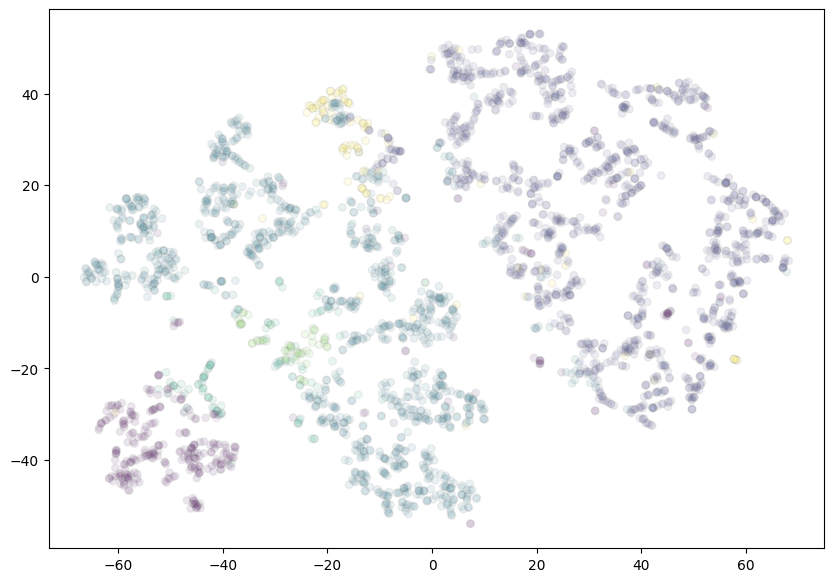

In [242]:
# Drop probability columns
X_preprocessed = X_clustered.drop(columns=prob_cols).values

# Calculating entropy (measure of uncertainty)
# High entropy = model is unsure which cluster to choose
from scipy.stats import entropy
probs = X_clustered[prob_cols].values
uncert = entropy(probs, axis=1) 


# Min-Max Scaling for entropy, to make differences visible 
# (and to have alpha between 0 and 1)
a_min, a_max = 0, 1
uncert_scaled = (uncert - uncert.min()) / (uncert.max() - uncert.min() + 1e-9)
alpha = a_min + (1 - uncert_scaled) * (a_max - a_min) 

# 2D Visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_preprocessed)


plt.figure(figsize=(10, 7))
# Color by cluster, but set transparency (alpha) or size (s) based on uncertainty
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
            c=np.argmax(probs, axis=1), 
            s=30, # fixed point size
            alpha=0.1 * alpha,
            cmap='viridis',
            edgecolors='grey',
            )

#### Hard Clustering

In [243]:
pipeline = pipeline_factory(
    n_components=best_linear_gmm_.params['n_clusters'],
    random_state=42,
    max_iter=1000,
    soft_clusters=False,
    use_ohe=False
)

pipeline.set_output(transform="pandas")

pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

In [244]:
from IPython.display import display, Markdown

labels = pipeline.named_steps['cluster_feat'].clusterer.labels_
display(Markdown("### Cluster label distribution:"))
display(pd.Series(labels).value_counts().rename_axis("cluster").rename("count").to_frame().T)


display(Markdown("### Cluster feature names:"))
print(pipeline.named_steps['cluster_feat'].get_feature_names_out())

### Cluster label distribution:

cluster,1,2,0,3,5,4
count,1301,1193,334,106,99,56


### Cluster feature names:

['op_align_A' 'op_align_B' 'op_align_S' 'stand_type_A' 'stand_type_B'
 'stand_type_C' 'stand_type_D' 'stand_type_E' 'op_w' 'op_l' 'wire_dia'
 'mesh_fl' 'mesh_sp' 'batch_width' 'batch_length' 'qty' 'warp_wire_count'
 'weft_wire_count' 'cross_section_count' 'wire_weight_per_meter'
 'batch_area' 'batch_volume' 'cluster_id']


In [245]:
from sklearn.manifold import TSNE

X_clustered = pipeline.transform(X_train)

# Cluster labels (as numeric values, before OHE)
cluster_labels = pipeline.named_steps['cluster_feat'].clusterer.predict(
    pipeline.named_steps['preprocess'].transform(
        pipeline.named_steps['feature_creation'].transform(X_train)
    ).values
).reshape(-1, 1)

# Scaled data (without cluster labels)
X_preprocessed = X_clustered.drop(columns=['cluster_id']).values

# t-SNE - reduction to 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_preprocessed)

# t-SNE - reduction to 3D
tsne_3d = TSNE(n_components=3, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(X_preprocessed)


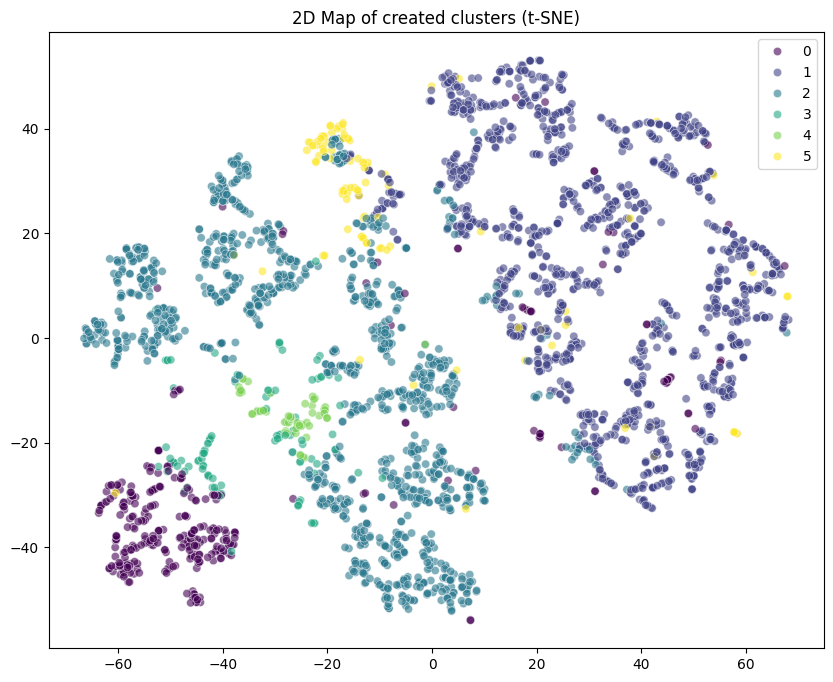

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_tsne[:,0], 
    y=X_tsne[:,1], 
    hue=cluster_labels.ravel(), 
    palette='viridis', 
    alpha=0.6
)
plt.title('2D Map of created clusters (t-SNE)')
plt.show()

In [247]:
import plotly.express as px

fig = px.scatter_3d(
    x=X_tsne_3d[:,0], 
    y=X_tsne_3d[:,1], 
    z=X_tsne_3d[:,2],
    size_max=5,
    color=cluster_labels.ravel(), # ravel to convert to 1D
    color_continuous_scale='viridis',
    title='3D Map of created clusters (t-SNE)',
    labels={'color': 'Cluster ID'}
)
fig.update_traces(marker=dict(size=2, opacity=0.6))
# defaults: 1.25, zoom: 0.8
fig.update_layout(scene=dict(camera=dict(eye=dict(x=0.8, y=0.8, z=0.8))))
fig.show()

---

#### Write MLflow Artifacts and Metrics

In [ ]:
best_linear_gmm_ = (
    pd.DataFrame(opt_results_lin)
    .dropna()[1]
    .apply(lambda s: {**s.best_trial.user_attrs, **{'params': s.best_trial.params}})
    .apply(pd.Series)
    .sort_values(by='RMSE').T[0]
)

best_tree_gmm_ = (
    pd.DataFrame(opt_results_tree)
    .dropna()[1]
    .apply(lambda s: {**s.best_trial.user_attrs, **{'params': s.best_trial.params}})
    .apply(pd.Series)
    .sort_values(by='RMSE').T[0]
)

In [232]:
# ========================================
# Best Linear Model Results Logging
# ========================================
with mlflow.start_run(run_name="linear_model_gmm_features") as run:
    print("Logging parameters and metrics of the best linear model...")
    mlflow.log_params(best_linear_gmm_.params)
    mlflow.log_metric("rmse", float(best_linear_gmm_.RMSE))
    mlflow.log_metric("mae", float(best_linear_gmm_.MAE))
    mlflow.log_metric("r2", float(best_linear_gmm_.R2))

    print("Best linear model parameters and metrics logged to MLflow.")

# ========================================
# Best XGBoost Model Results Logging
# ========================================
with mlflow.start_run(run_name="tree_model_gmm_features") as run:
    print("Logging parameters and metrics of the best tree model...")
    mlflow.log_params(best_tree_gmm_.params)
    mlflow.log_metric("rmse", float(best_tree_gmm_.RMSE))
    mlflow.log_metric("mae", float(best_tree_gmm_.MAE))
    mlflow.log_metric("r2", float(best_tree_gmm_.R2))

    print("Best tree model parameters and metrics logged to MLflow.")

Logging parameters and metrics of the best linear model...
Best linear model parameters and metrics logged to MLflow.
Logging parameters and metrics of the best tree model...
Best tree model parameters and metrics logged to MLflow.


In [233]:
from notebooks.utils.utilities.get_run_metrics import get_latest_metrics_for_run
from mlflow.tracking import MlflowClient

client = MlflowClient()

for run_name in ["linear_model_gmm_features", "tree_model_gmm_features"]:
    get_latest_metrics_for_run(run_name=run_name, client=client, verbose=True)


Latest run of 'linear_model_gmm_features' metrics:
--------------------------------------------------
Best RMSE: 39.41726931894874
Best MAE: 18.274110435616087
Best R2: 0.8378102955170267
Model parameters:
  model_type: Ridge
  use_clusterer: True
  use_gmm_ohe: True
  variance_penalty: False
  n_clusters: 6
  soft_clusters: True
  ridge_alpha: 0.008260808399079604

Latest run of 'tree_model_gmm_features' metrics:
--------------------------------------------------
Best RMSE: 40.27711944580078
Best MAE: 18.05176658630371
Best R2: 0.8330150127410889
Model parameters:
  model_type: XGBRegressor
  use_clusterer: True
  use_gmm_ohe: False
  variance_penalty: False
  n_clusters: 6
  soft_clusters: True
  xgb_n_estimators: 131
  xgb_max_depth: 3
  xgb_learning_rate: 0.0641582348791348
  xgb_min_child_weight: 4
  xgb_subsample: 0.9709605973908264
  xgb_colsample_bytree: 0.7432450392917341


run names for later retrieval of metrics:
- linear_model_gmm_features
- tree_model_gmm_features

---
---